# Exercises for Chapter 14, "Working with logistic regression"

In [57]:
import os
import sys

import numpy

from matplotlib import pyplot
from scipy import special

sys.path.append(os.path.abspath("/home/bgawalt/ros"))
import bg_ros

In [58]:
prng_builder = bg_ros.PRNGBuilder("""
    This is Chapter 14, wherein our heroes work with logistic regression in
    fun and fascinating ways.  I'm doing these exercises well after actually
    reading the material so I'll have to page a lot of it back in as it goes.
    I think it's... mostly adding interaction features?  We'll see.
""")

## 14.1, Graphing binary data and logistic regression

> Reproduce Figure 14.1 with the model,
> $\text{Pr}(y =1) = \text{logit}^{-1}(0.4 - 0.3x)$, with 50 data points $x$
> sampled uniformly in the range $[A, B]$. (In Figure 14.1 the $x$’s were drawn
> from a normal distribution.) Choose the values $A$ and $B$ so that the plot
> includes a zone where values of $y$ are all 1, a zone where they are all 0,
> and a band of overlap in the middle.

In [59]:
rng = prng_builder.new('Exercise 14.1, reproducing a figure')

In [60]:
a, b = (0.4, -0.3)

In [61]:
# From the logistic probability density function, we want the latent
# linear-predictor variable z to range from -6 to 6.
hi = (-6 - a) / b
lo = (6 - a) / b
print(f'[A, B] = [{lo: 0.1f}, {hi: 0.1f}]')

[A, B] = [-18.7,  21.3]


In [62]:
xs = rng.uniform(low=lo, high=hi, size=50)
zs = a + b * xs
rs = rng.uniform(size=50)
ys = [1 if ri < si else 0 for (ri, si) in zip(rs, special.expit(zs))]

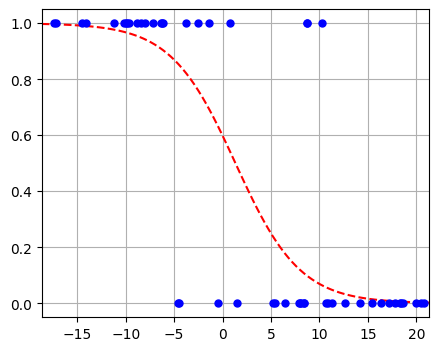

In [63]:
fig = pyplot.figure(figsize=(5, 4))
ax = fig.gca()
ax.plot(
    numpy.linspace(lo, hi, 100),
    special.expit(a + b * numpy.linspace(lo, hi, 100)),
    'r--',
)
ax.plot(xs, ys, 'b.', markersize=10)
ax.grid()
ax.set_xlim(lo, hi)
ax.set_axisbelow(True)
        

## 14.2, Logistic regression and discrimination lines

> Reproduce Figure 14.2 with the model,
> $\text{Pr}(y = 1) = \text{logit}^{-1}(0.4 - 0.3x_1 + 0.2x_2)$, with $(x1, x2)$
> sampled uniformly from the rectangle $[A_1, B_1] \times [A_2, B_2]$. Choose
> the values $A_1, B_1, A_2, B_2$ so that the plot includes a zone where values
> of $y$ are all 1, a zone where they are all 0, and a band of overlap in the
> middle, and with the three lines corresponding to
> $\text{Pr}(y = 1) = 0.1, 0.5,$ and 0.9 are all visible.

In [64]:
rng = prng_builder.new('Exercise 14.2, reproducing a whole nother figure')

In [65]:
a, b1, b2 = (0.4, -0.3, 0.2)
n = 150  # Num. points to sample

B1 = (-6 - a) / b1
A1 = (6 - a) / b1
A2 = (-6 - a) / b2
B2 = (6 - a) / b2

print(f'[A1, B1] = [{A1:0.1f}, {B1:0.1f}]')
print(f'[A2, B2] = [{A2:0.1f}, {B2:0.1f}]')

[A1, B1] = [-18.7, 21.3]
[A2, B2] = [-32.0, 28.0]


In [70]:
x1s = rng.uniform(low=A1, high=B1, size=n)
x2s = rng.uniform(low=A2, high=B2, size=n)
zs = a + b1 * x1s + b2 * x2s
rs = rng.uniform(size=n)
ys = [1 if ri < si else 0 for (ri, si) in zip(rs, special.expit(zs))]

In [86]:
def add_logreg_line(ax: pyplot.Axes, p: float, style: str):
    logit_p = special.logit(p)
    # a + b1 x1 + b2 x2 = logit_p
    # --> x2 = intercept + slope x1
    intercept = (logit_p - a) / b2
    slope = -1 * b1 / b2
    ax.plot(
        [A1, B1],
        [
            intercept + slope * A1,
            intercept + slope * B1,
        ],
        color='k',
        linestyle=style,
        linewidth=1,
        zorder=999,
    )

Text(0, 0.5, 'x2')

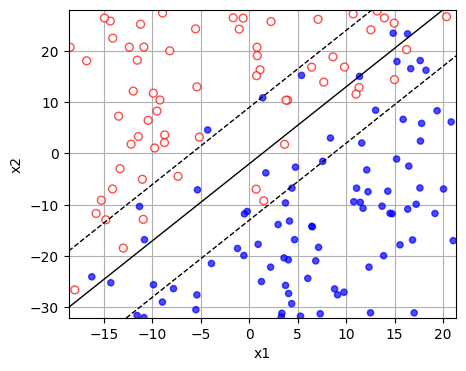

In [87]:
fig = pyplot.figure(figsize=(5, 4))
ax = fig.gca()
add_logreg_line(ax, 0.1, '--')
add_logreg_line(ax, 0.5, '-')
add_logreg_line(ax, 0.9, '--')
ax.scatter(
    x1s,
    x2s,
    s=[32 if yi == 1 else 20 for yi in ys],
    c=['w' if yi == 1 else 'b' for yi in ys],
    edgecolors=['r' if yi == 1 else 'b' for yi in ys],
    alpha=0.7,
)
ax.grid()
ax.set_xlim(lo, hi)
ax.set_axisbelow(True)
ax.set_xlim(A1, B1)
ax.set_ylim(A2, B2)
ax.set_xlabel('x1')
ax.set_ylabel('x2')